# Two-Dimensional `Transmitter`

This notebook provides an empirical demonstration of the expected behavior of a two-dimensional `Transmitter`. Its purpose is to make the module's learning dynamics observable in a simple setting in which they can be studied in isolation, rather than to exhaustively validate every implementation detail.

Two capabilities are examined. First, the `Transmitter` starts without prior knowledge about which outputs are preferable and progressively reshapes its sampling distribution from the rewards it receives. Second, once a distribution has been learned, the same state can be sampled with different biases to make the policy flatter, sharper, or even preference-reversing without retraining it.

## Conceptual Overview

Within Jacinta, a `Transmitter` is responsible for choosing output stimuli: the continuous coordinates emitted by the processing system. In this two-dimensional example, an output stimulus is a pair of real numbers in a bounded rectangular region. The module does not produce a fixed prediction or directly optimize a coordinate. Instead, it maintains a probability distribution over all valid outputs and samples from that distribution whenever `forward()` is called. After the consequence of the sample is known, `backward()` uses the resulting scalar reward to influence future choices.

The learning loop is therefore:

1. `forward()` samples a `TransmitterSample` from the current distribution.
2. The environment evaluates that sample and returns a reward.
3. `backward()` converts the reward into a learning signal and updates the distribution.

At initialization, the `Transmitter` has no evidence favoring any part of the output space. Its tree consists of one rectangle with zero log-weight, so sampling is uniform over the complete domain. Preferences emerge only from interaction with the environment.

### How the distribution is represented

Representing an arbitrary continuous distribution directly would normally require either a fixed discretization or a predefined parametric family. The `Transmitter` avoids both by specializing `NDSpace`, Jacinta's tree-based representation of continuous space. In two dimensions, every leaf of the tree represents an axis-aligned rectangle. Sampling is hierarchical: at each internal node, a softmax over the log-weights of its children selects a branch; after a leaf is reached, a coordinate is drawn uniformly from that leaf's bounds.

The resulting density is piecewise constant. Its shape depends on two distinct forms of adaptation:

- **Probability adaptation:** feedback changes the log-weights associated with the sampled path, altering how likely the existing regions are to be selected.
- **Spatial refinement:** frequently visited leaves are split at their midpoint, allowing the model to distinguish smaller regions where additional resolution is useful.

These mechanisms are related but not interchangeable. Updating weights can express a preference only between regions that already exist; splitting creates the finer regions between which future preferences can be learned.

The configured `Evaluator` converts each raw reward into an advantage relative to a running baseline. When an advantage is available, `backward()` adds a learning-rate-scaled update to every node on the sampled path, from the selected region back to the root. Positive advantages reinforce that path, whereas negative advantages suppress it. All nodes in the tree share the same evaluator, so rewards are compared against one global history rather than against independent baselines for individual regions.

When a leaf reaches its visit threshold, it attempts to split at its midpoint. In this two-dimensional case, a split therefore produces four equal rectangular children. The new children begin with equal log-weights, so the probability mass already assigned to the parent is initially divided symmetrically between them. The parent retains its accumulated weight, preserving what has already been learned about the broader region while the children begin learning how that probability should be distributed more precisely.

### Scope of the demonstration

The reward function used below is stationary: a coordinate always receives the same reward. This isolates the output-side learning behavior and makes the resulting changes easy to interpret. The notebook therefore demonstrates dynamic adaptation *from sequential feedback*, but it does not test how quickly the module tracks a reward landscape that changes over time.

A standalone `Transmitter` is also context-independent. It receives reward feedback but no input stimulus describing the situation in which an output was requested. In Jacinta, contextual adaptation is introduced on the input side: a `Receiver` partitions the input space and associates different `Transmitter` instances with different input regions, while `Processor` combines both modules into an adaptive input-output mapping. The present experiment deliberately omits that layer so that the `Transmitter` can be examined on its own.

In [1]:
import math
from collections.abc import Callable

import matplotlib.pyplot as plt
from matplotlib import colormaps
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

from jacinta.processor.evaluator import ZScoreEvaluator
from jacinta.processor.transmitter import Transmitter
from jacinta.utils.scheduler import ConstantScheduler

## Configuration

The parameters below are chosen to make the relevant behavior visible within a short, reproducible run. They provide enough interactions for preferences to develop and for several local splits to occur, but they should not be interpreted as general-purpose defaults.

The output domain is the half-open square $[-10, 10)\times[-10,10)$. The half-open convention follows `NDSpace`: the lower bound of each dimension is included and the upper bound is excluded. Independently of the coordinate ranges, `Transmitter.backward()` accepts feedback only in $[-1, 1]$; an external environment must therefore bound or normalize its rewards before passing them to the module.

### Reward evaluation and weight updates

A raw reward describes the outcome of one sample, but its learning value depends on how that outcome compares with the recent reward history. `ZScoreEvaluator` supplies this comparison by maintaining exponential moving estimates of the global mean and variance. Both EMA rates are set to `0.001`, giving recent observations influence over an approximate timescale of one thousand interactions. The evaluator uses its first observations to initialize those statistics and subsequently returns a standardized advantage.

The learning-rate scheduler is also fixed at `0.001`. Whenever the evaluator returns an advantage, that value is multiplied by the learning rate and added to the log-weight of every node on the sampled path. The small step size makes preferences accumulate gradually rather than allowing a single reward to dominate the distribution.

### Spatial refinement

Weight updates change the relative probability of existing branches, but they cannot add spatial detail. Refinement is controlled independently by `HITS_RATE = 1000`: after a leaf has been sampled one thousand times, it attempts to split at its midpoint. A lower threshold would produce finer partitions sooner, based on less evidence; a higher threshold would keep the representation coarse for longer.

`MIN_WIDTH = 1` provides the stopping condition for refinement. A split is rejected if any child would be narrower than one unit along any dimension. Because both initial dimensions have width 20 and every split is a bisection, the smallest side length reachable in this configuration is 1.25 units. `MAX_DEPTH` can therefore remain `None`, since the minimum-width constraint already places a finite bound on the tree depth.

Refinement is driven by visits rather than by geometric coverage. Regions that acquire more probability are sampled more often and consequently tend to split sooner. This coupling concentrates representational capacity where the current policy spends most of its interactions, while low-probability regions may remain comparatively coarse.

### Schedulers, bias, and reproducibility

Bias scale, learning rate, and hit rate are depth-dependent parameters in the `Transmitter` API. This notebook wraps each value in a `ConstantScheduler`, so the same setting is used at every depth. Other schedulers can make deeper regions learn, split, or respond to sampling bias differently.

`BIAS_SCALE = 10.0` determines the strength of the sampling transformation examined in the final section. It does not affect training here because the learning run always calls `forward(bias=0.0)`. `SEED = 42` makes the stochastic trajectory reproducible, `N_STEPS = 10000` supplies enough interactions for several refinements, and `N_PLOTS = 5` records approximately evenly spaced snapshots of the evolving distribution.

In [2]:
MIN_X, MAX_X = -10.0, 10.0
MIN_Y, MAX_Y = -10.0, 10.0
MIN_Z, MAX_Z = -1.0, 1.0

# hyperparameters
MEAN_EMA_RATE = 0.001
VAR_EMA_RATE = 0.001
BIAS_SCALE = 10.0
LEARNING_RATE = 0.001
HITS_RATE = 1000
MIN_WIDTH = 1
MAX_DEPTH = None
SEED = 42

# simulation parameters
N_STEPS = 10000
N_PLOTS = 5

## Visualization Utilities

The `Transmitter` stores its distribution implicitly as a weighted tree, not as a standalone probability-density function. The following helpers reconstruct the density solely for inspection; they do not participate in sampling, evaluation, or learning.

`get_leaves()` follows every root-to-leaf path and reproduces the same biased softmax calculations used by `forward()`. The probability of reaching a leaf is then divided by the area of its rectangular region. This conversion is important: the branch-selection process assigns probability *mass* to each leaf, whereas the plot displays probability *density*. A small and a large leaf can therefore have the same probability mass but different heights in the graph.

`plot_transmitter()` renders the resulting piecewise-constant density as a collection of rectangular bars. Their horizontal boundaries expose the current tree partition, and each bar's height represents density within that region. The color encodes the same quantity for visual emphasis. Since the probability masses of all leaves sum to one, the total integral of the displayed density over the complete output space is also one.

`eval_function()` and `plot_function()` evaluate the reward function over the same domain and clip displayed values to the feedback range accepted by `backward()`. Plotting the reward landscape beside the learned density makes it possible to compare where high rewards exist with where the `Transmitter` has learned to allocate probability.

In [3]:
def eval_function(
    function: Callable[[float, float], float], x: float, y: float
) -> float:
    """
    Safely evaluate a function for the given values.

    Args:
        function (Callable[[float, float], float]): The function to evaluate.
        x (float): The first value to evaluate the function at.
        y (float): The second value to evaluate the function at.

    Returns:
        float: The result of the function evaluation.
    """
    try:
        z = function(x, y)
        if not math.isfinite(z):
            z = math.nan
        z = max(min(z, MAX_Z), MIN_Z)
    except (ArithmeticError, ValueError):
        z = math.nan
    return z

In [4]:
def plot_function(
    ax: plt.Axes,
    function: Callable[[float, float], float],
    n_points: int = 100,
    elev: float = 30.0,
    azim: float = 30.0,
) -> None:
    """
    Plot a function.

    Args:
        ax (plt.Axes): The axes to plot on.
        function (Callable[[float, float], float]): The function to plot.
        n_points (int): The number of points to plot per dimension.
            Defaults to 100.
        elev (float): The elevation of the viewing angle.
            Defaults to 30.0.
        azim (float): The azimuth of the viewing angle.
            Defaults to 30.0.
    """
    # evaluate the function
    x_step = (MAX_X - MIN_X) / (n_points - 1)
    y_step = (MAX_Y - MIN_Y) / (n_points - 1)
    x_vals = [MIN_X + idx * x_step for idx in range(n_points)]
    y_vals = [MIN_Y + idx * y_step for idx in range(n_points)]
    x_grid = [x_val for y_val in y_vals for x_val in x_vals]
    y_grid = [y_val for y_val in y_vals for x_val in x_vals]
    z_grid = [
        eval_function(function, x_val, y_val) for y_val in y_vals for x_val in x_vals
    ]
    # build the mesh triangles
    triangles = []
    for row in range(n_points - 1):
        for col in range(n_points - 1):
            # build the mesh cell
            top_left = row * n_points + col
            top_right = top_left + 1
            bottom_left = (row + 1) * n_points + col
            bottom_right = bottom_left + 1
            # split the cell into two triangles
            triangles.append([top_left, top_right, bottom_right])
            triangles.append([top_left, bottom_right, bottom_left])
    # plot the function
    ax.plot_trisurf(
        x_grid,
        y_grid,
        z_grid,
        triangles=triangles,
        cmap="viridis",
        antialiased=False,
    )
    ax.view_init(elev=elev, azim=azim)
    ax.set_xlim(MIN_X, MAX_X)
    ax.set_ylim(MIN_Y, MAX_Y)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.zaxis.set_rotate_label(False)
    ax.set_zlabel("f(x, y)", rotation=90)
    ax.set_title(f"Reward Function (elev={elev}, azim={azim})")
    ax.grid(visible=True)
    return

In [5]:
def get_leaves(
    transmitter: Transmitter, probability: float = 1.0, bias: float = 0.0
) -> list[tuple[Transmitter, float]]:
    """
    Get the transmitter leaves with their probability densities.

    Args:
        transmitter (Transmitter): The transmitter to get the leaves of.
        probability (float): The probability of the transmitter being selected.
            Defaults to 1.0.
        bias (float): The bias to apply to the log-weights.
            Defaults to 0.0.

    Returns:
        list[tuple[Transmitter, float]]: A list of tuples containing the transmitter
            leaves and their probability densities.
    """
    # check if the transmitter is a leaf
    if transmitter.is_leaf:
        x_lower, x_upper = transmitter.bounds[0]
        y_lower, y_upper = transmitter.bounds[1]
        # compute the probability density of the leaf
        probability_density = probability / ((x_upper - x_lower) * (y_upper - y_lower))
        leaves = [(transmitter, probability_density)]
    # otherwise, recursively get its leaves
    else:
        log_weights = [child.log_weight for child in transmitter.children]
        # bias the log-weights
        bias_scale = 1.0 + bias * transmitter.bias_scale_scheduler(transmitter.depth)
        log_weights = [log_weight * bias_scale for log_weight in log_weights]
        # stable log-weights with softmax
        max_log_weight = max(log_weights)
        weights = [math.exp(log_weight - max_log_weight) for log_weight in log_weights]
        # get the transmitter leaves
        leaves = []
        total_weight = sum(weights)
        for child, weight in zip(transmitter.children, weights, strict=True):
            # compute the probability of the child being selected
            child_probability = probability * weight / total_weight
            child_leaves = get_leaves(child, child_probability, bias)
            leaves.extend(child_leaves)
    return leaves

In [6]:
def plot_transmitter(
    ax: plt.Axes,
    transmitter: Transmitter,
    bias: float = 0.0,
    elev: float = 30.0,
    azim: float = 30.0,
) -> None:
    """
    Plot the probability density function of a transmitter.

    Args:
        ax (plt.Axes): The axes to plot on.
        transmitter (Transmitter): The transmitter to plot.
        bias (float): The bias to apply to the log-weights.
            Defaults to 0.0.
        elev (float): The elevation of the viewing angle.
            Defaults to 30.0.
        azim (float): The azimuth of the viewing angle.
            Defaults to 30.0.
    """
    # get the transmitter leaves
    leaves = get_leaves(transmitter, bias=bias)
    # sort the leaves by their lower bounds
    leaves.sort(key=lambda leaf: (leaf[0].bounds[0][0], leaf[0].bounds[1][0]))
    # get the probability density of each leaf
    probability_densities = [probability_density for _, probability_density in leaves]
    # disable automatic 3D z-order
    ax.computed_zorder = False
    # normalize the probability densities for the color map
    max_density = max(probability_densities)
    if max_density == 0.0:
        max_density = 1.0
    normalize = Normalize(vmin=0.0, vmax=max_density)
    # set the height of the color bar
    z_max = max_density * 1.05
    colorbar_height = max_density / z_max
    colorbar_ax = ax.inset_axes(
        [1.02, 0.0, 0.04, colorbar_height],
        transform=ax.transAxes,
    )
    # plot the color bar
    colormap = colormaps["RdYlGn"]
    scalar_mappable = ScalarMappable(norm=normalize, cmap=colormap)
    scalar_mappable.set_array([])
    ax.figure.colorbar(scalar_mappable, cax=colorbar_ax)
    # color each rectangle according to its probability density
    for leaf, probability_density in leaves:
        x_lower, x_upper = leaf.bounds[0]
        y_lower, y_upper = leaf.bounds[1]
        color = colormap(normalize(probability_density))
        ax.bar3d(
            x_lower,
            y_lower,
            0.0,
            x_upper - x_lower,
            y_upper - y_lower,
            probability_density,
            color=color,
        )
    # plot the transmitter
    ax.view_init(elev=elev, azim=azim)
    ax.set_xlim(MIN_X, MAX_X)
    ax.set_ylim(MIN_Y, MAX_Y)
    ax.set_zlim(0.0, z_max)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.zaxis.set_rotate_label(False)
    ax.set_zlabel("Probability Density", rotation=90)
    ax.set_title(
        "Transmitter Probability Density Function "
        f"(bias={bias}, elev={elev}, azim={azim})"
    )
    ax.grid(visible=True)
    return

## Reward Function

The `Transmitter` needs an environment that evaluates each sampled coordinate. In this playground, the environment is represented by a deterministic reward function: evaluating the same coordinate always returns the same reward. This controlled setting makes the evolution of the learned distribution easier to interpret.

The function combines several smooth peaks and valleys. Its global maximum is approximately 1.0 near $(x,y)=(-2.80,2.70)$. Lower positive peaks appear near $(-6.7,-3.8)$, $(5.6,-5.2)$, and $(3.8,5.8)$, while the most pronounced minimum, approximately -1.0, lies near $(2.20,-2.10)$. Additional negative regions make the landscape deliberately multimodal. A single broad optimum would make preference learning easy to observe, but it would reveal less about whether the policy can preserve alternatives while concentrating probability around the best region it has identified.

The plotted surface is shown for explanation, but it is not available to the `Transmitter`. The module receives neither the function, its derivatives, nor the locations of its extrema. At each interaction it observes only the coordinate it sampled and the scalar reward returned for that coordinate. The task is therefore not function approximation: it is online adaptation of a sampling policy so that future samples achieve higher expected reward.

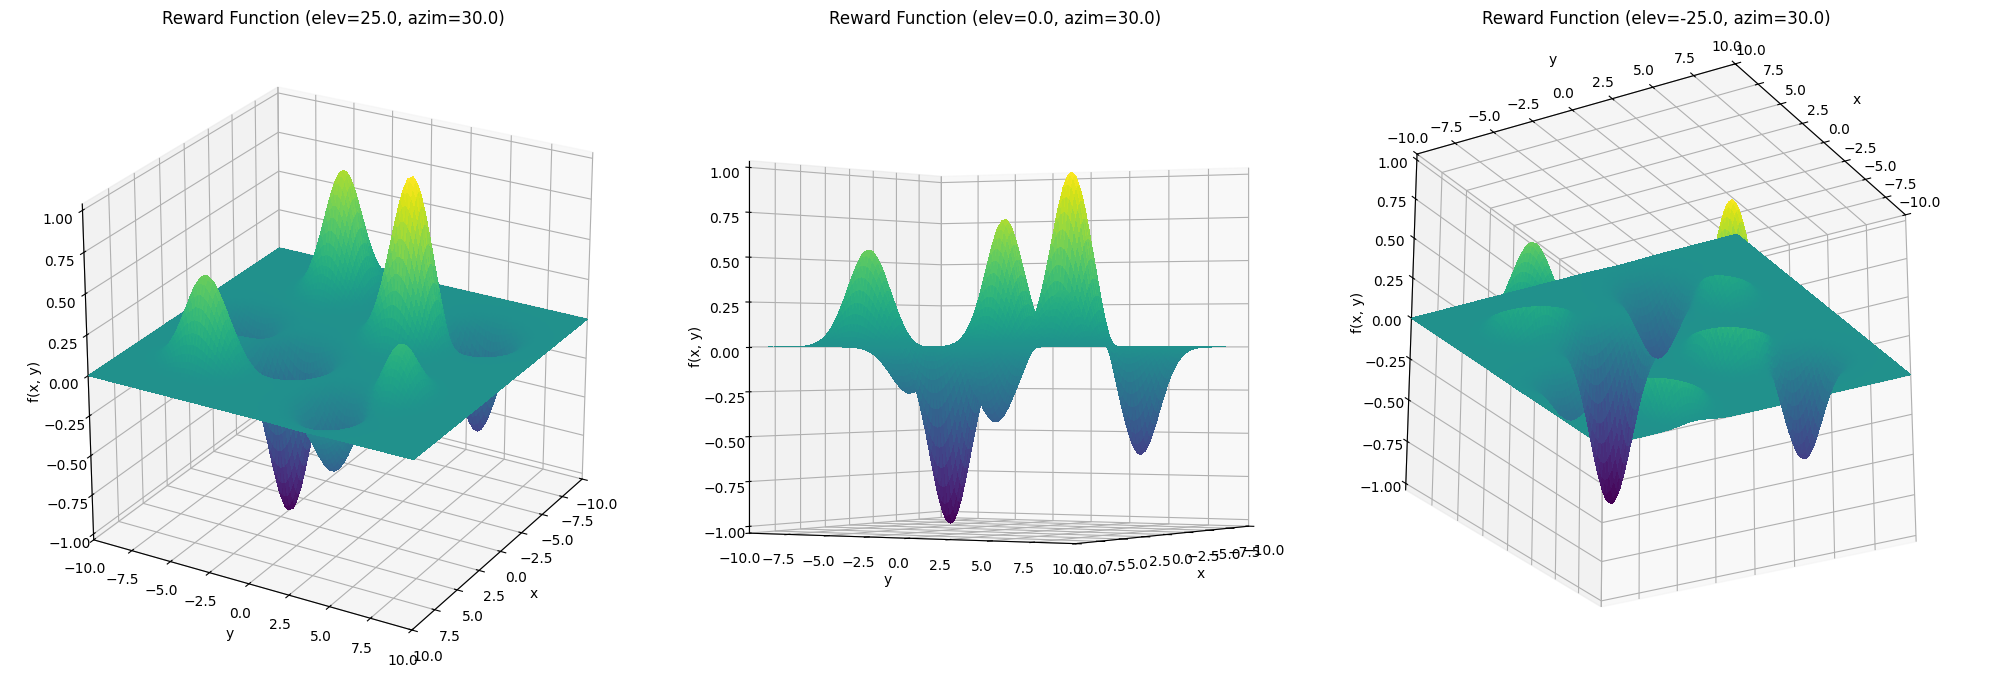

In [7]:
def reward_function(x: float, y: float) -> float:
    """
    Reward function.

    Args:
        x (float): The first value to evaluate the function at.
        y (float): The second value to evaluate the function at.

    Returns:
        float: The result of the function evaluation.
    """
    z = (
        0.9988 * math.exp(-(((x + 2.8) / 1.7) ** 2 + ((y - 2.7) / 1.5) ** 2))
        + 0.7550 * math.exp(-(((x + 6.7) / 1.8) ** 2 + ((y + 3.8) / 1.4) ** 2))
        + 0.5450 * math.exp(-(((x - 5.6) / 1.3) ** 2 + ((y + 5.2) / 1.7) ** 2))
        + 0.3150 * math.exp(-(((x - 3.8) / 1.5) ** 2 + ((y - 5.8) / 1.2) ** 2))
        - 0.9993 * math.exp(-(((x - 2.2) / 1.5) ** 2 + ((y + 2.1) / 1.6) ** 2))
        - 0.6200 * math.exp(-(((x + 5.2) / 1.4) ** 2 + ((y - 5.7) / 1.5) ** 2))
        - 0.4100 * math.exp(-(((x - 6.4) / 1.7) ** 2 + ((y - 3.2) / 1.4) ** 2))
        - 0.2700 * math.exp(-(((x + 0.8) / 1.3) ** 2 + ((y + 6.5) / 1.6) ** 2))
    )
    return z


# plot the reward function
fig, ax = plt.subplots(ncols=3, figsize=(20, 7), subplot_kw={"projection": "3d"})
plot_function(ax[0], reward_function, elev=25.0)
plot_function(ax[1], reward_function, elev=0.0)
plot_function(ax[2], reward_function, elev=-25.0)
# adjust the aspect ratio of each plot
for axis in ax:
    axis.set_box_aspect((1, 1, 1), zoom=0.95)
fig.tight_layout()
plt.show()

## Simulation

The `Transmitter` is now trained through repeated `forward()` and `backward()` calls. It begins as a single leaf spanning the complete region. With no children to choose between and no prior weight information, the initial sample is uniform over $[-10,10)\times[-10,10)$, whose area is 400 and whose density is therefore $1/400=0.0025$. The random seed makes the stochastic trajectory reproducible.

Each iteration executes the complete interaction cycle:

1. `forward(bias=0.0)` samples a coordinate from the current learned distribution.
2. `reward_function()` returns the reward associated with that coordinate.
3. `backward()` records the visit, asks the shared `ZScoreEvaluator` for an advantage, and updates the log-weights along the sampled path whenever an advantage is available.

The call uses `bias=0.0` throughout training. Consequently, the displayed distribution is the distribution implied directly by the accumulated log-weights, without any additional transformation of the sampling probabilities. Two kinds of change should be read separately in the plots: new rectangular boundaries indicate refinement of the spatial partition, while changes in bar height indicate changes in learned probability density.

### Reading the snapshots

The first snapshot remains uniform because only one interaction has occurred and the root has not yet reached its split threshold. Once the root has accumulated one thousand visits, it divides at zero along both dimensions, producing the four quadrants $[-10,0)\times[-10,0)$, $[-10,0)\times[0,10)$, $[0,10)\times[-10,0)$, and $[0,10)\times[0,10)$. At that moment, all four children begin with equal log-weights. Their probabilities diverge only as subsequent samples from those regions receive different advantages.

By step 2,501, the four quadrants already have visibly different probability densities. The negative-$x$ half contains the two strongest positive peaks in the reward landscape, including the global maximum near $(-2.80,2.70)$, and its regions become increasingly competitive with the positive-$x$ half, which includes the strongest negative valley near $(2.20,-2.10)$. Because higher-probability regions are then visited more frequently, they also accumulate the evidence required for further splitting sooner. This is the expected coupling between policy and representation: probability determines where samples are spent, and samples determine where additional spatial resolution is created.

By step 5,001, refinement is already concentrated in the negative-$x$ half of the domain, while substantial parts of the positive-$x$ half remain comparatively coarse. The newly created children allow the `Transmitter` to distinguish the individual reward structures that were previously grouped inside the broader quadrants.

By step 7,500, the strongest density has emerged in the region surrounding the global positive peak. In particular, the cell $[-5,0)\times[0,5)$ contains the global maximum near $(-2.80,2.70)$ and is visibly preferred over neighboring regions. Other parts of the domain retain nonzero probability, including regions associated with the lower local maxima.

In the final snapshot, this same region remains the dominant leaf. Its probability density is approximately $0.0063$, substantially above the initial uniform density of $0.0025$. Since the region has area 25, this corresponds to roughly 16% of the total probability mass being assigned to that single $5\times5$ cell. Lower-reward regions retain smaller but nonzero probabilities, and several of them remain spatially coarser because they have been sampled less often.

The final distribution exhibits the intended qualitative behavior: probability has shifted toward the highest-reward region encountered, spatial resolution has increased where interactions were concentrated, and alternative regions remain available for sampling.

In [8]:
# initialize a 2D Transmitter
transmitter = Transmitter(
    bounds=((MIN_X, MAX_X), (MIN_Y, MAX_Y)),
    evaluator=ZScoreEvaluator(MEAN_EMA_RATE, VAR_EMA_RATE),
    bias_scale_scheduler=ConstantScheduler(value=BIAS_SCALE),
    learning_rate_scheduler=ConstantScheduler(value=LEARNING_RATE),
    hits_rate_scheduler=ConstantScheduler(value=HITS_RATE),
    min_width=MIN_WIDTH,
    max_depth=MAX_DEPTH,
    seed=SEED,
)

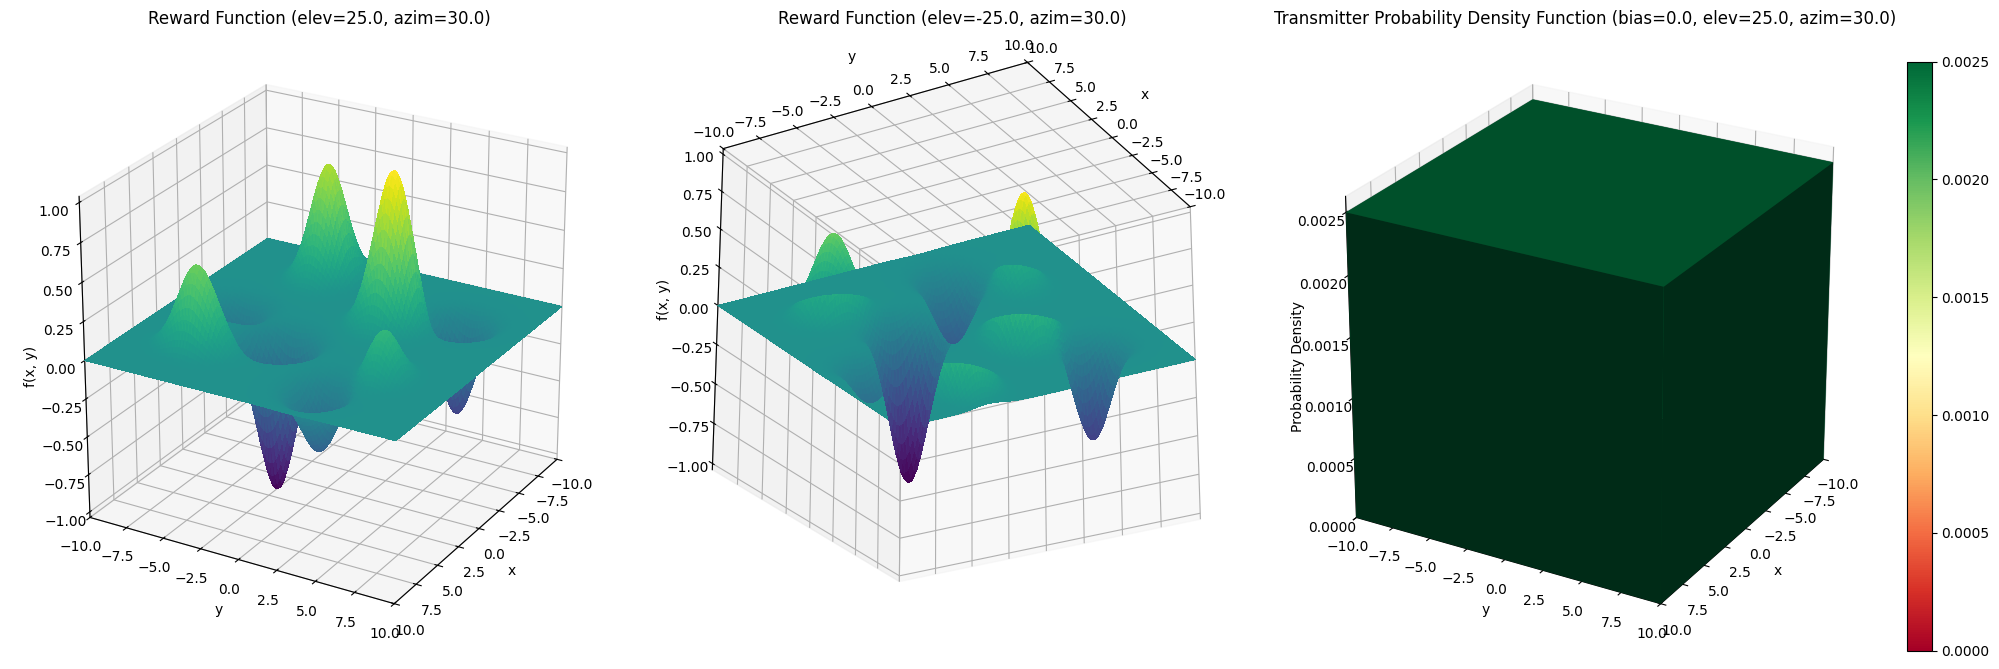

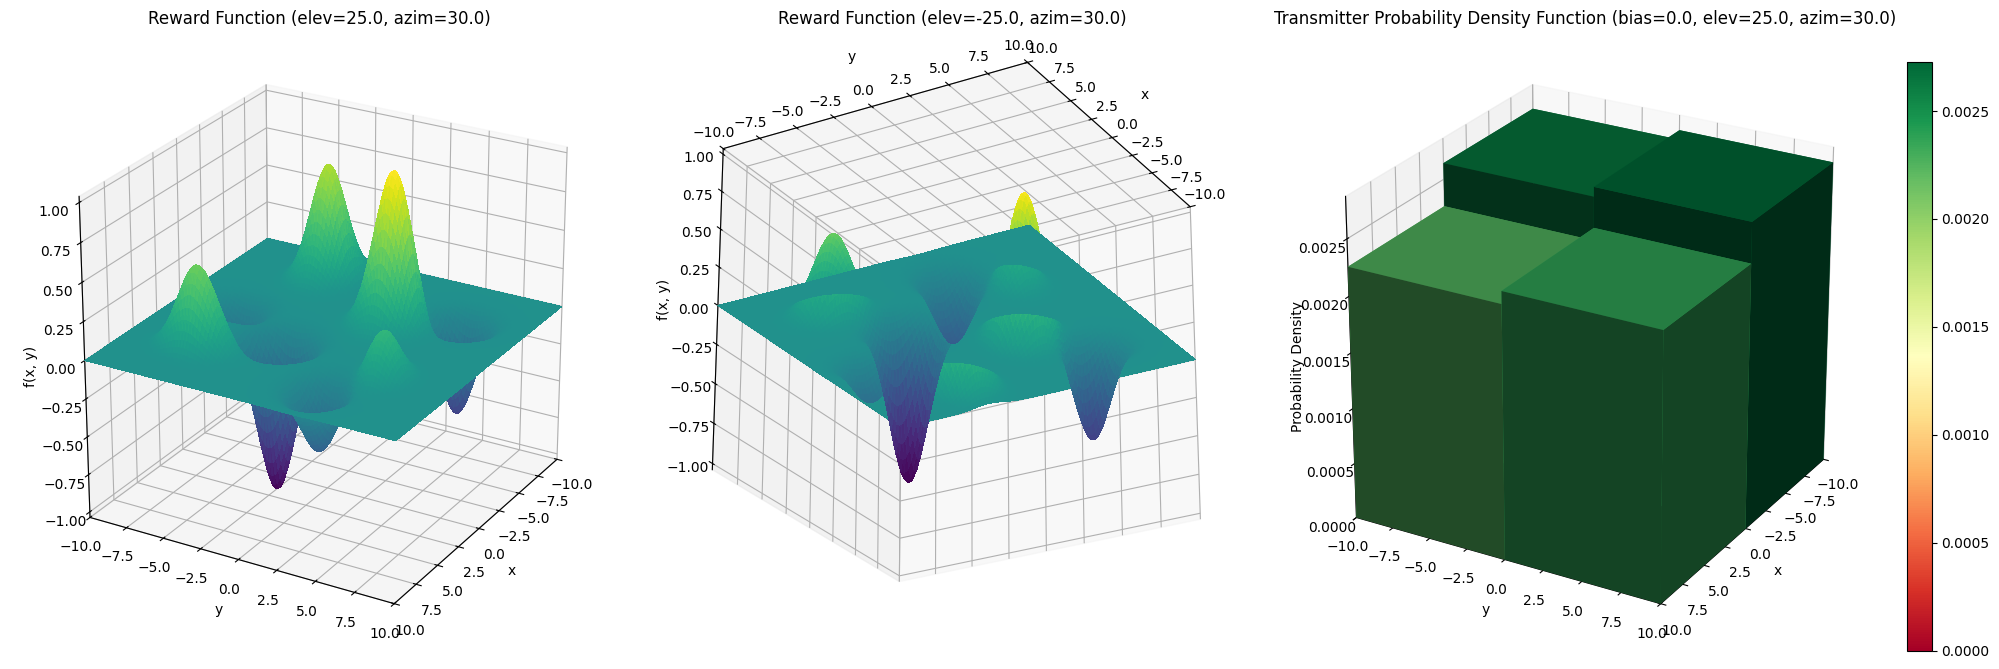

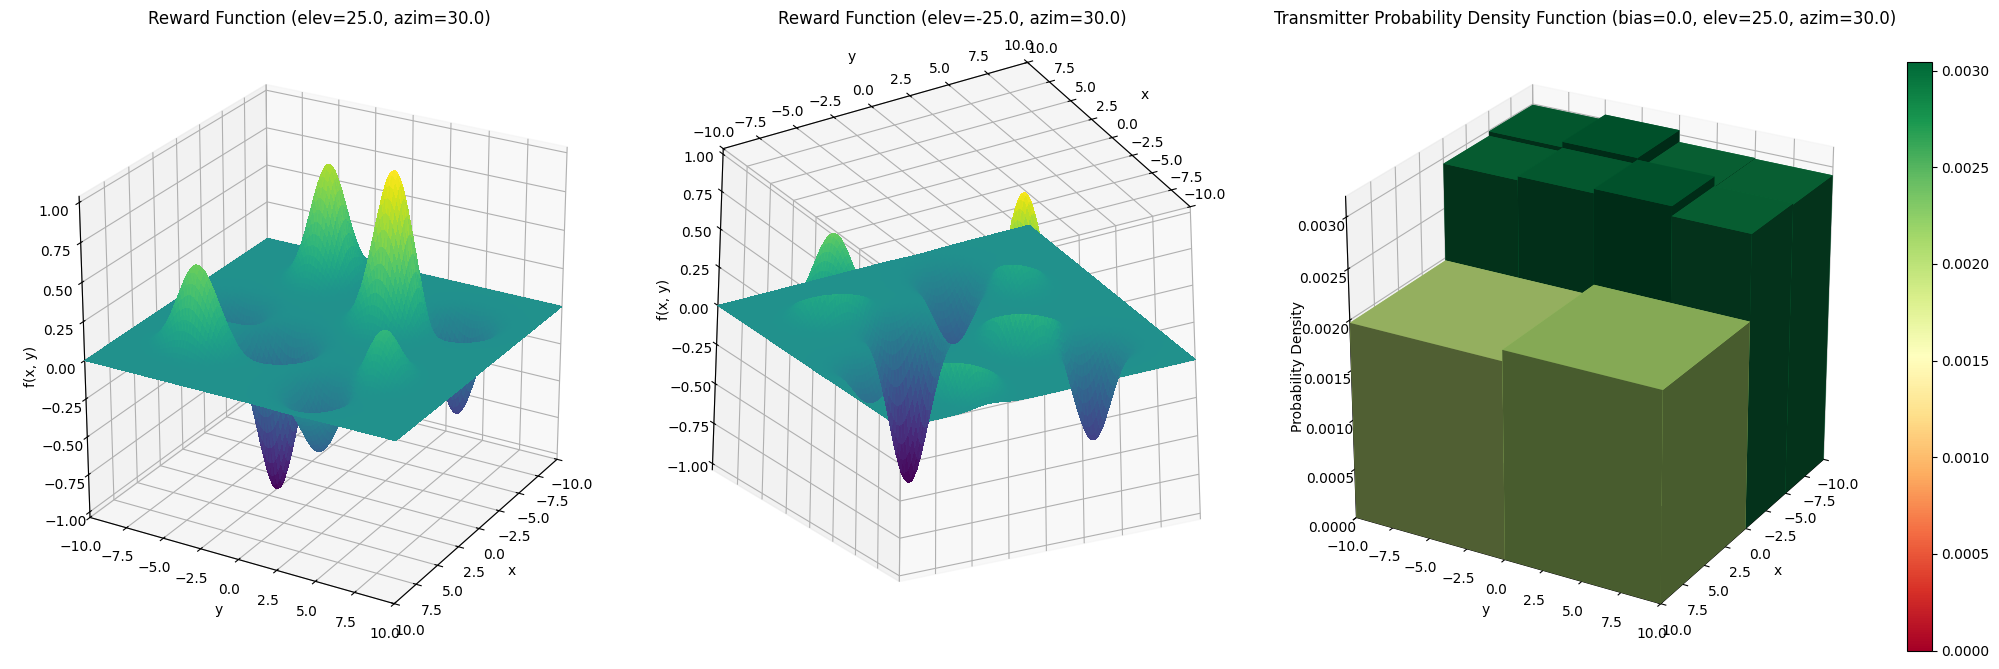

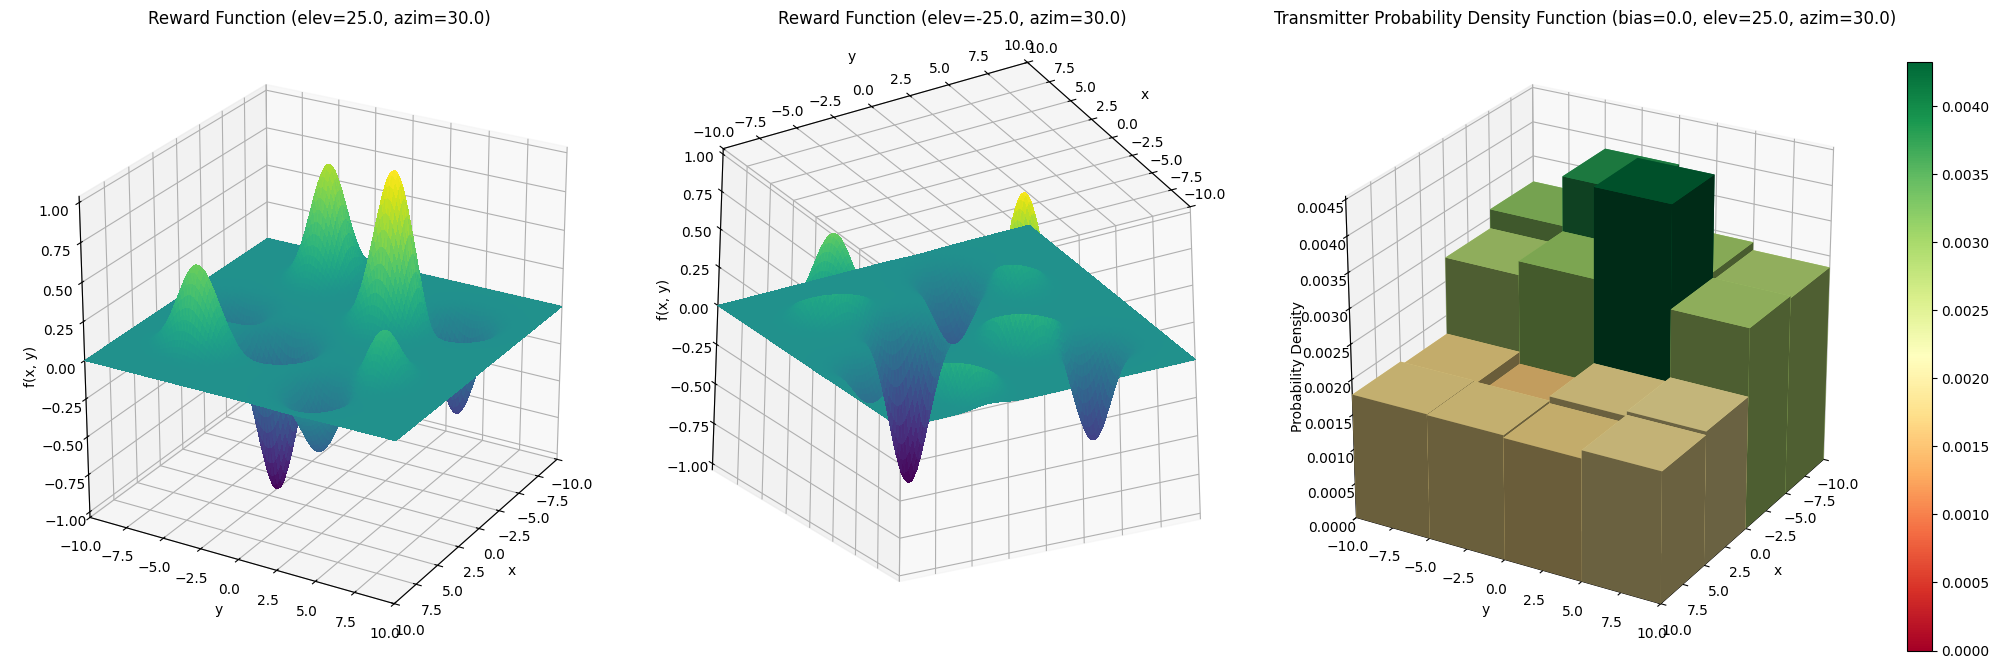

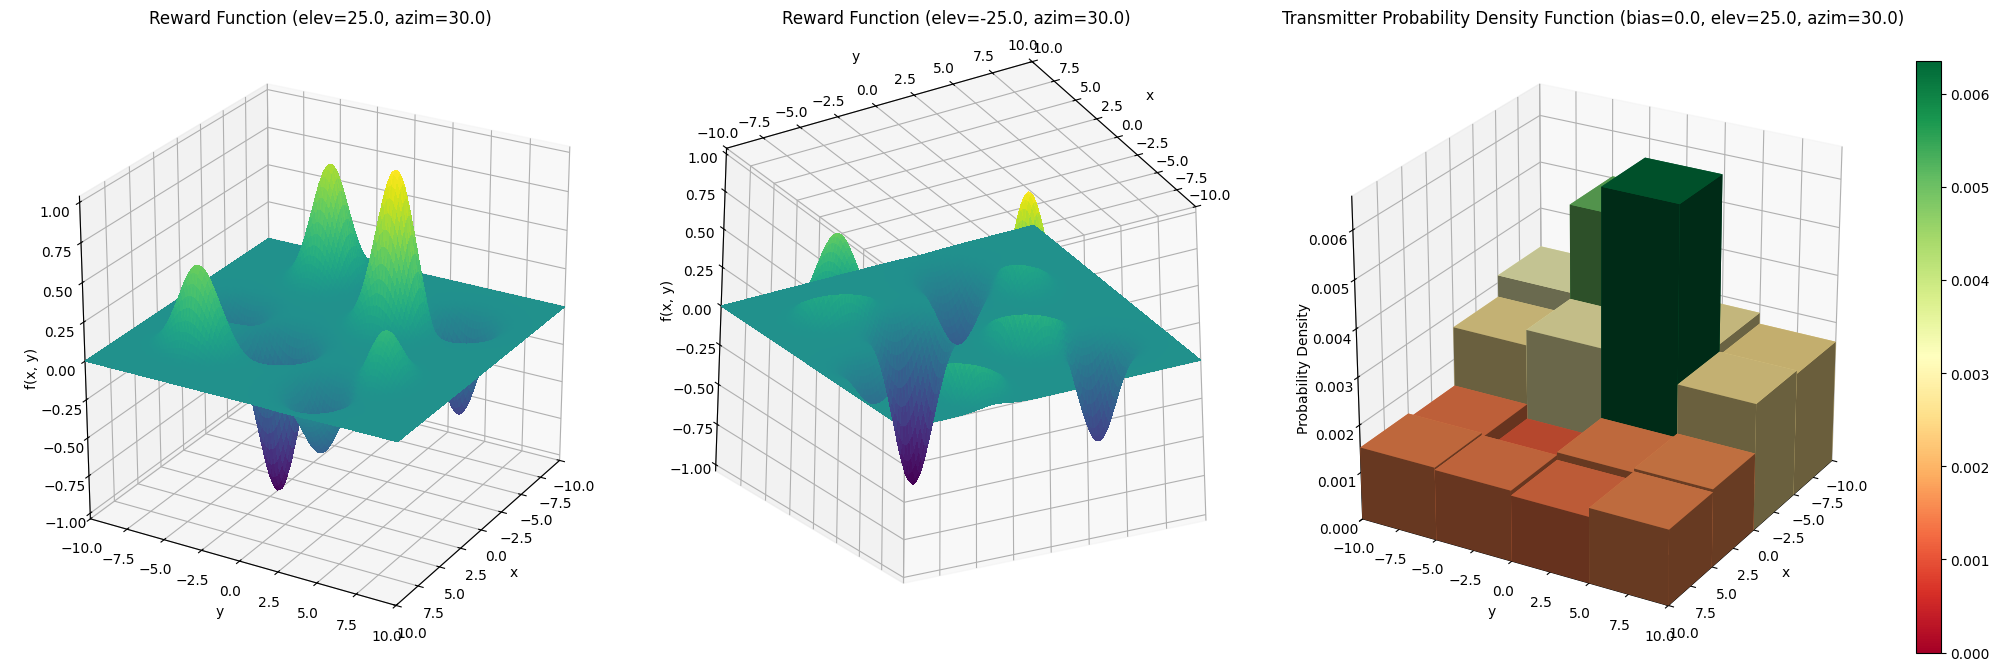

In [9]:
# set the transmitter plot steps
plot_steps = (
    {round(idx * (N_STEPS - 1) / (N_PLOTS - 1)) for idx in range(N_PLOTS)}
    if N_PLOTS > 1
    else {N_STEPS - 1}
)

# run simulation
for step in range(N_STEPS):
    print(f"Step {step + 1}/{N_STEPS}", end="\r")
    tsample = transmitter.forward(bias=0.0)
    reward = reward_function(tsample.coordinates[0], tsample.coordinates[1])
    transmitter.backward(tsample, reward)
    # plot the transmitter
    if step in plot_steps:
        fig, ax = plt.subplots(
            ncols=3, figsize=(20, 7), subplot_kw={"projection": "3d"}
        )
        plot_function(ax[0], reward_function, elev=25.0)
        plot_function(ax[1], reward_function, elev=-25.0)
        plot_transmitter(ax[2], transmitter, bias=0.0, elev=25.0)
        # adjust the aspect ratio of each plot
        for axis in ax:
            axis.set_box_aspect((1, 1, 1), zoom=0.95)
        fig.tight_layout()
        plt.show()

## Biased Sampling

Training with `bias=0.0` produces a neutral learned distribution: samples follow the preferences encoded in the stored log-weights. At inference time, however, a caller may want a broader policy that explores alternatives or a sharper policy that exploits the strongest preference. The `bias` argument provides that control without modifying the learned state.

At every internal node, `forward()` multiplies the children's log-weights by

$$m(b,d)=1+b\,S(d),$$

where $b\in[-1,1]$ is the requested bias and $S(d)$ is the bias-scale scheduler evaluated at depth $d$. The transformed values are then passed through the softmax. In this experiment, $S(d)=10$ at every depth, so the multiplier is $m=1+10b$.

This operation changes the contrast between branch preferences:

| Bias range | Sampling behavior |
|:---|:---|
| $b>0$ | $m>1$: differences between log-weights are amplified, producing a sharper and more exploitative distribution. |
| $b=0$ | $m=1$: sampling follows the learned distribution unchanged. |
| $-0.1<b<0$ | $0<m<1$: differences are compressed. The learned ranking is preserved, but the distribution becomes flatter and more exploratory. |
| $b=-0.1$ | $m=0$: all children of every internal node are equiprobable. Because every split divides a region into equal-sized children, the resulting density is uniform over the original region, even when different branches have different depths. |
| $b<-0.1$ | $m<0$: the ordering of the learned log-weights is reversed, so branches that were normally disfavored become preferred. |

The plots below show representative values from each regime. Biases `-1.0` and `-0.15` invert the learned preferences; `-0.1` cancels them and recovers a uniform density; `-0.05` flattens the distribution while preserving its ordering; `0.0` leaves it unchanged; and `0.25` and `1.0` increasingly concentrate probability in the preferred branches.

Even a strong positive bias does not convert the policy into a literal argmax: the softmax assigns positive probability to every finite-weight branch. Conversely, a strongly negative bias is not merely “more exploration.” Once the multiplier crosses zero, sampling actively favors the inverse of the learned ranking. Conventional exploratory flattening is therefore restricted, in this configuration, to the interval $-0.1<b<0$.

The bias transformation is applied only while a sample is being drawn. It does not overwrite log-weights, alter the evaluator, change the partition, or otherwise retrain the `Transmitter`. Multiple sampling policies can therefore be derived from exactly the same learned state.

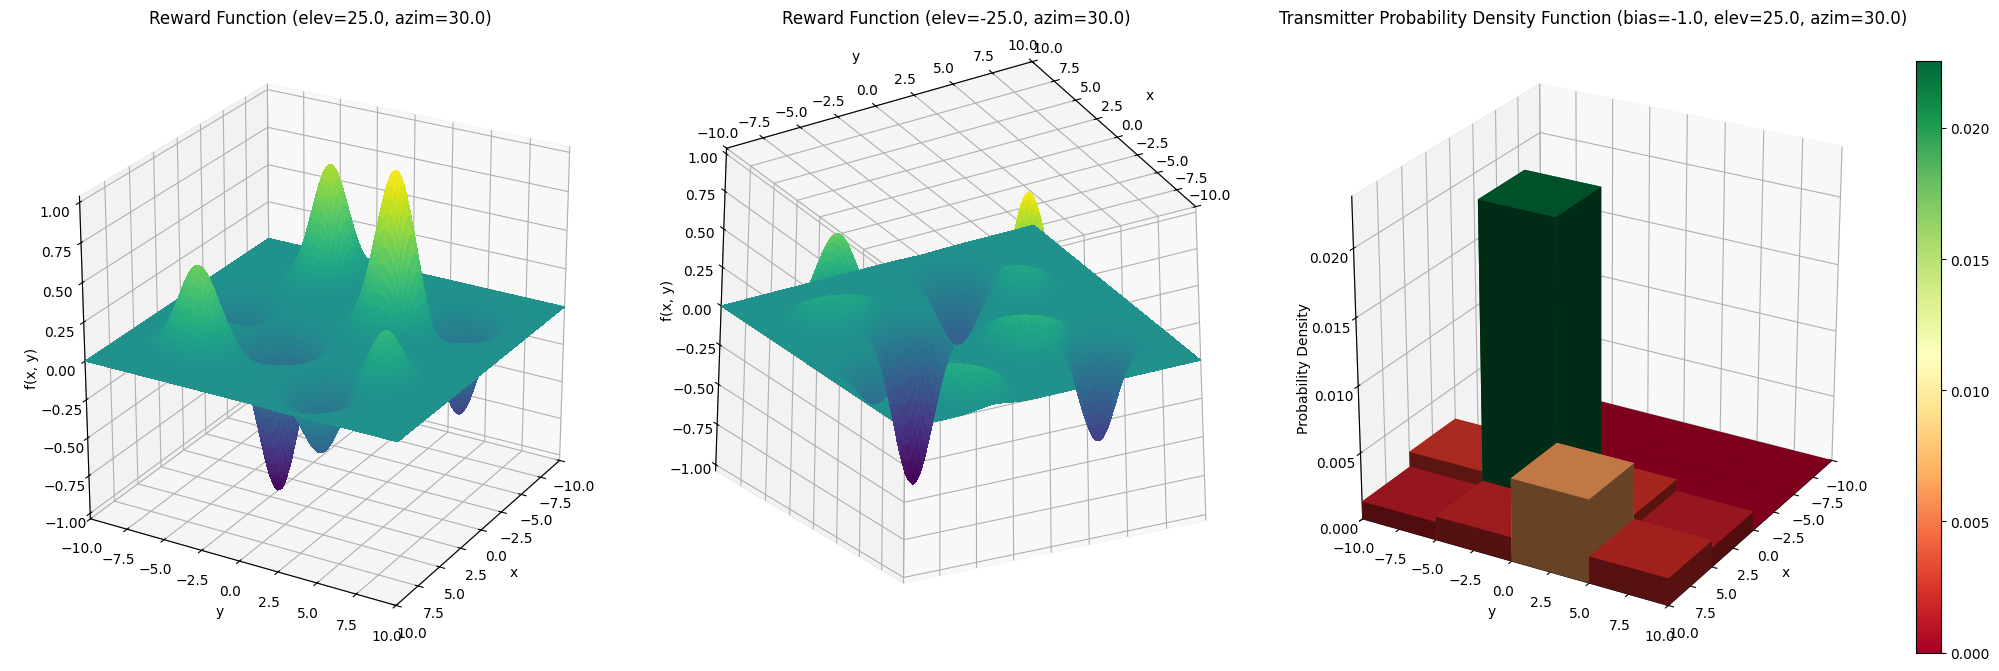

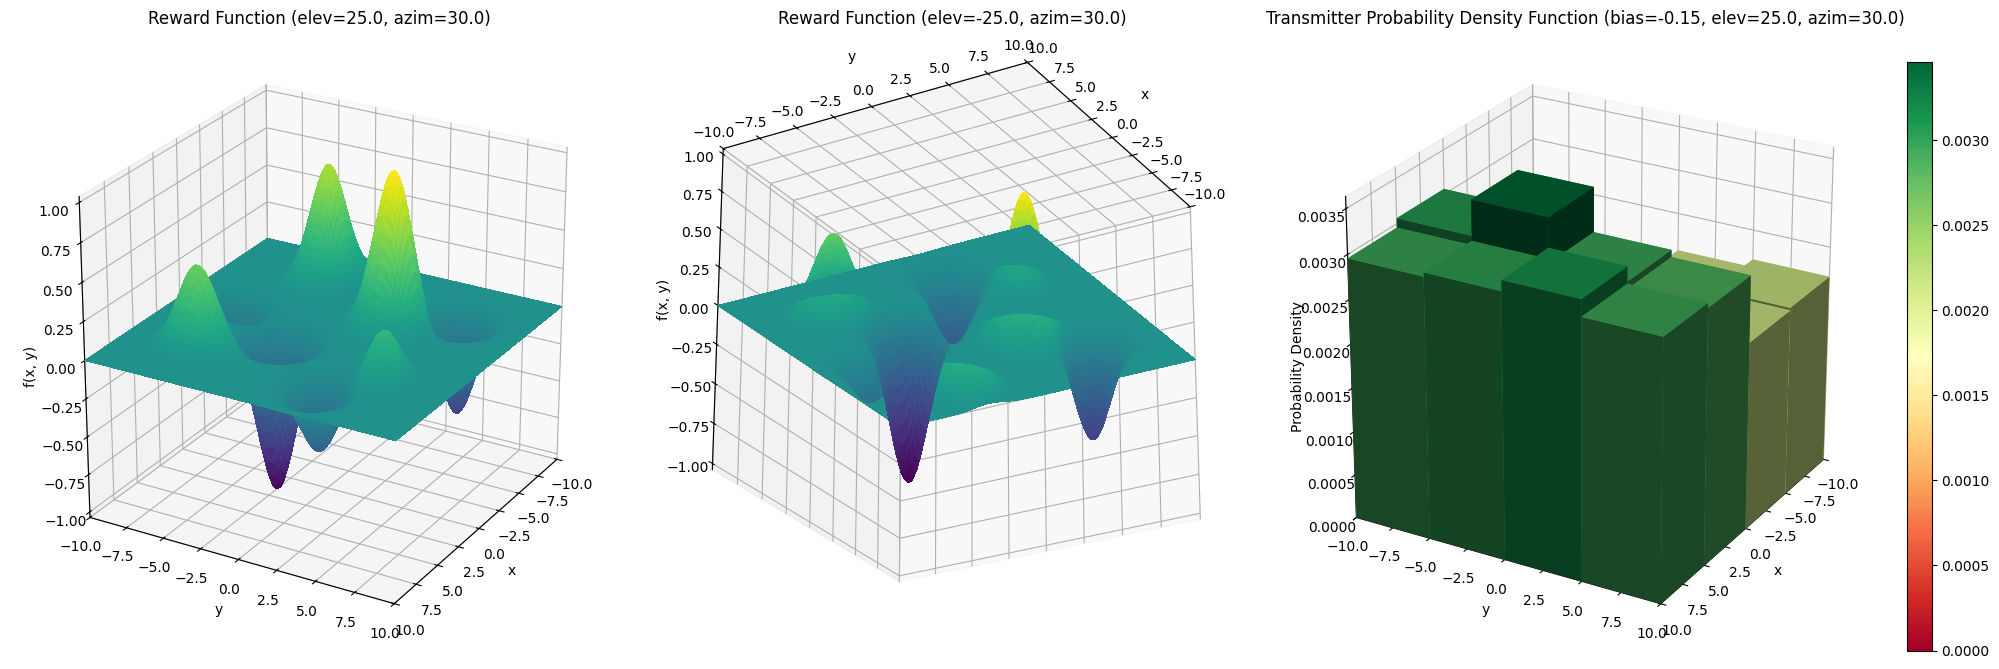

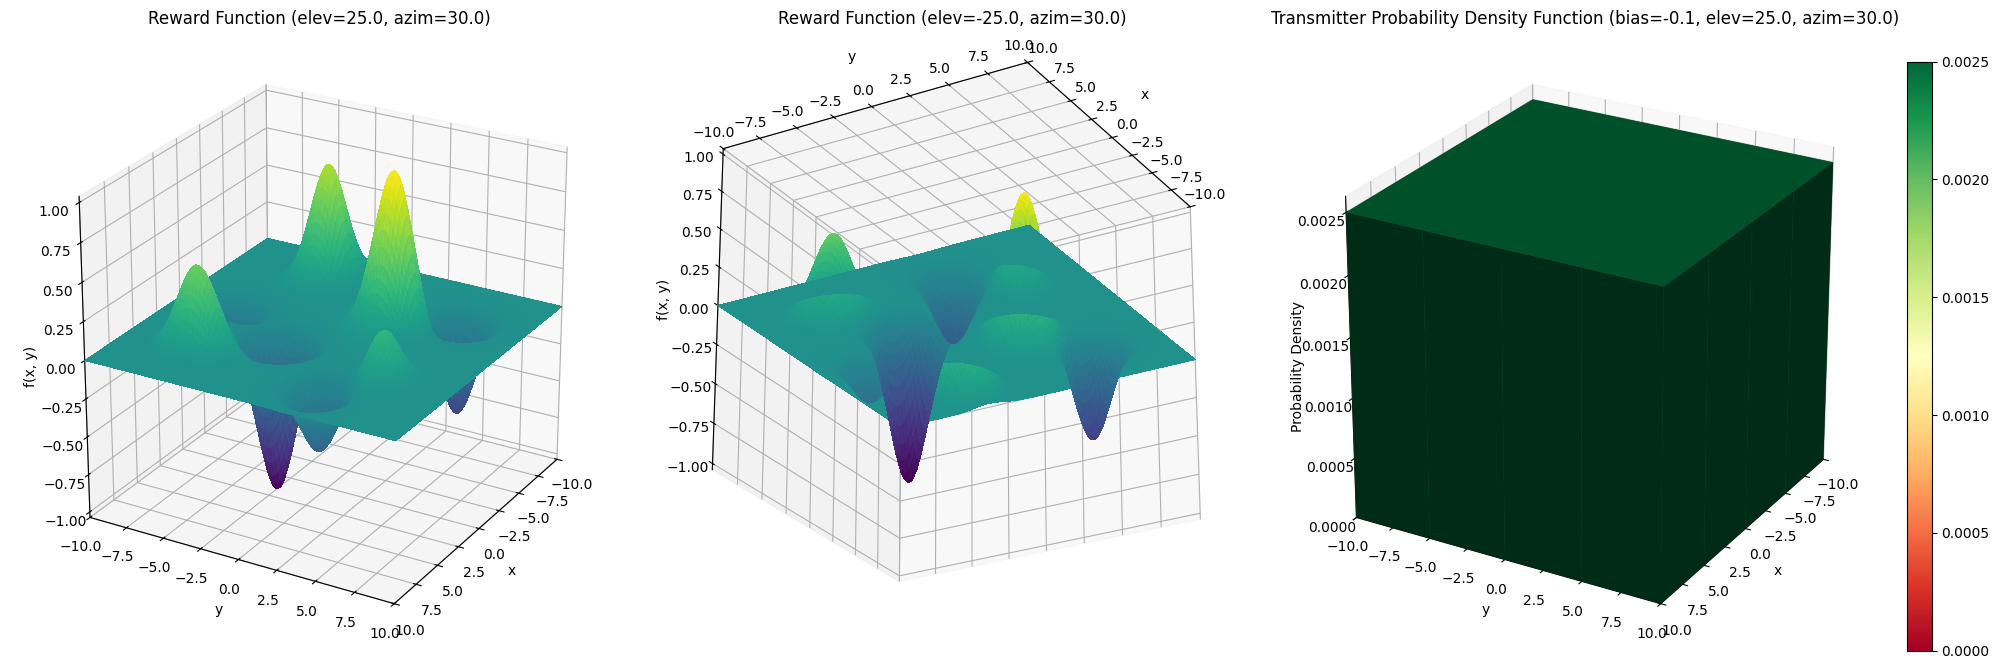

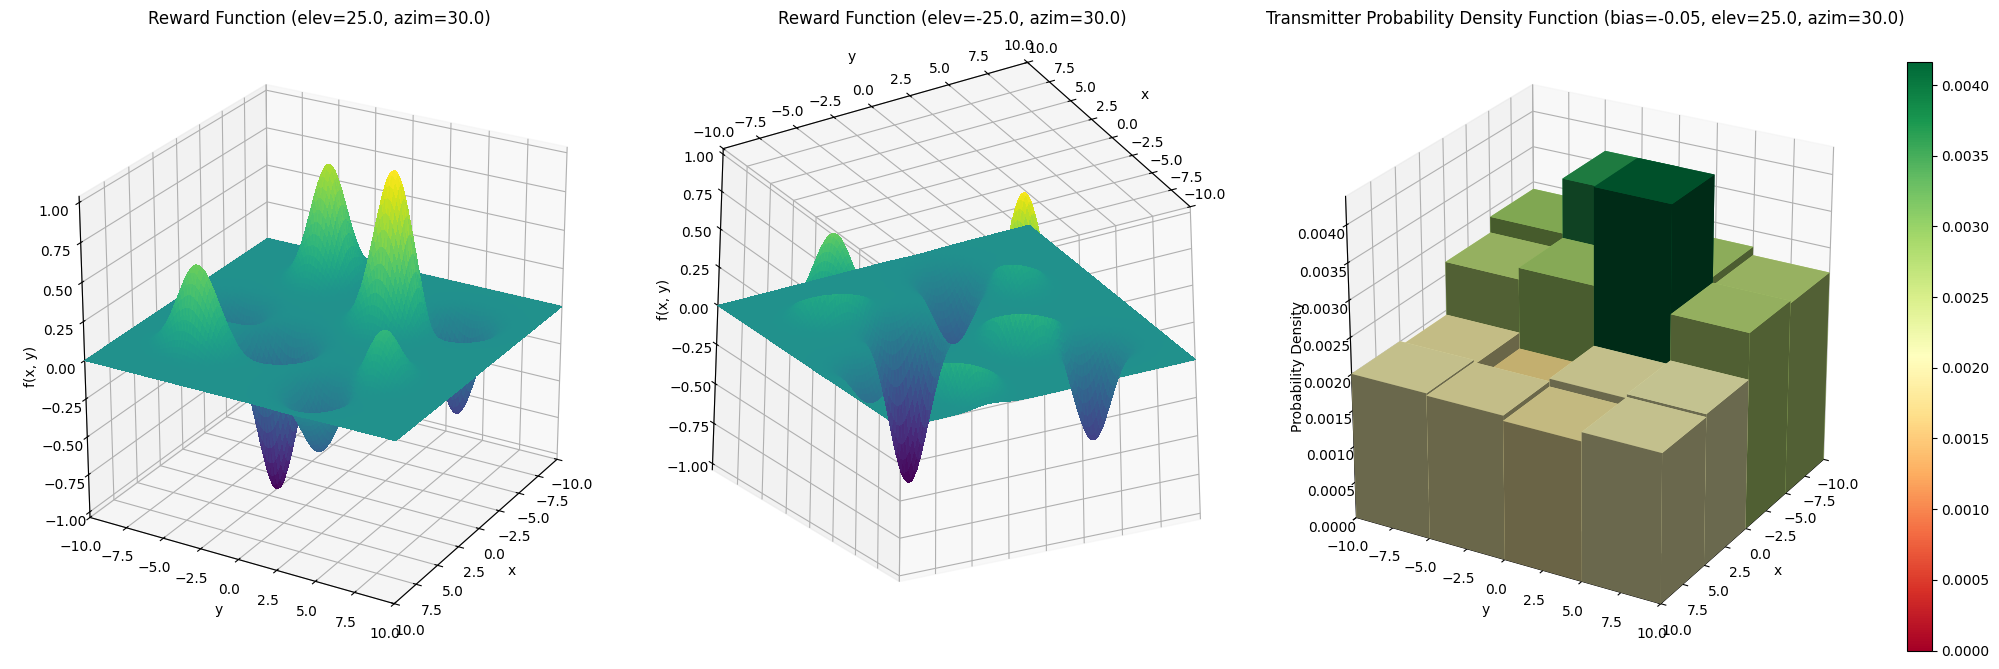

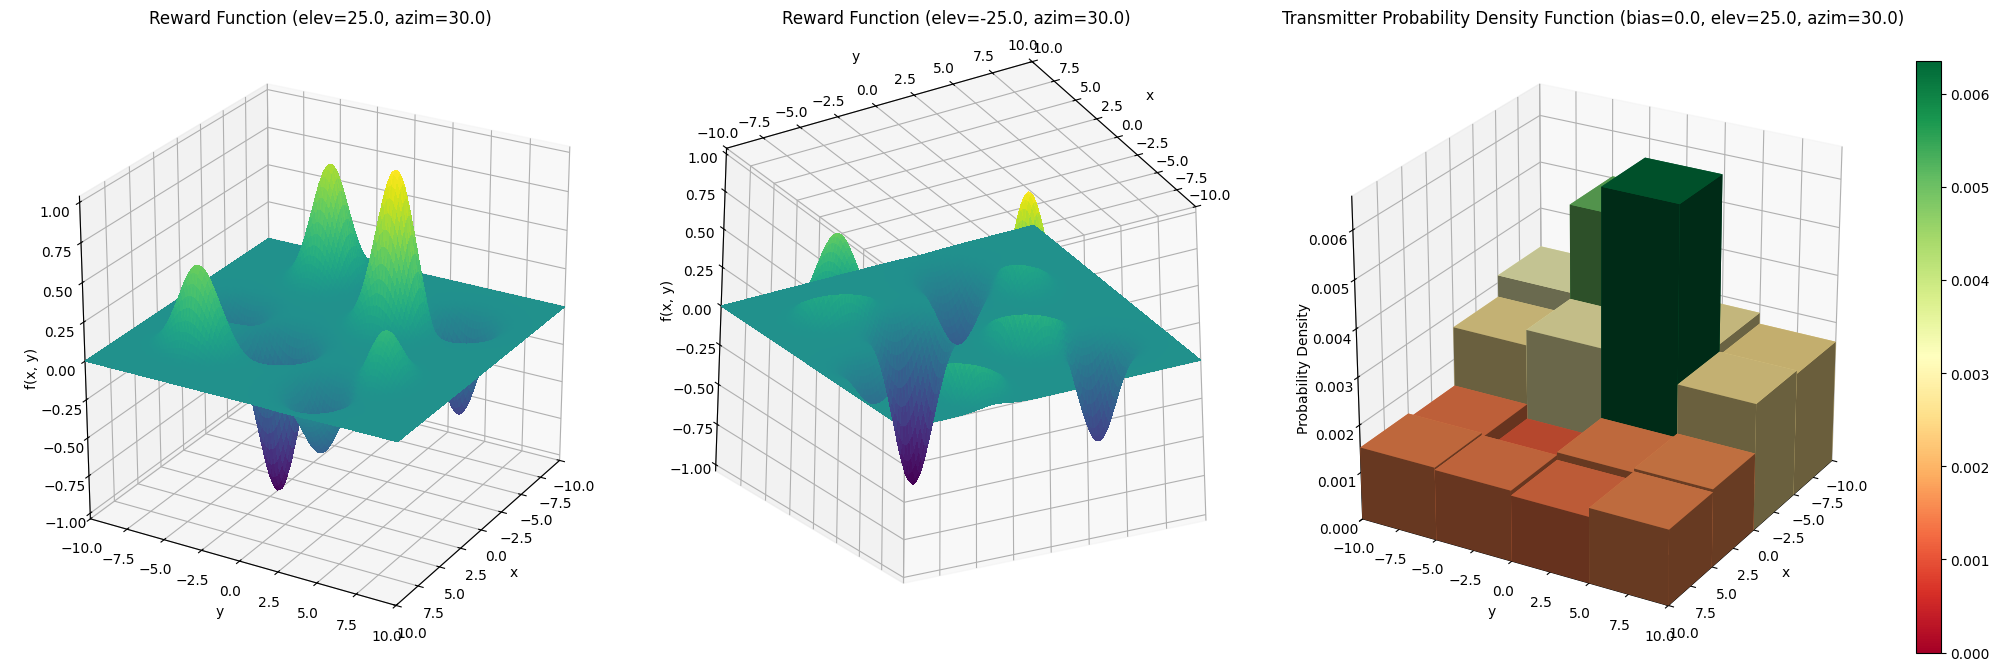

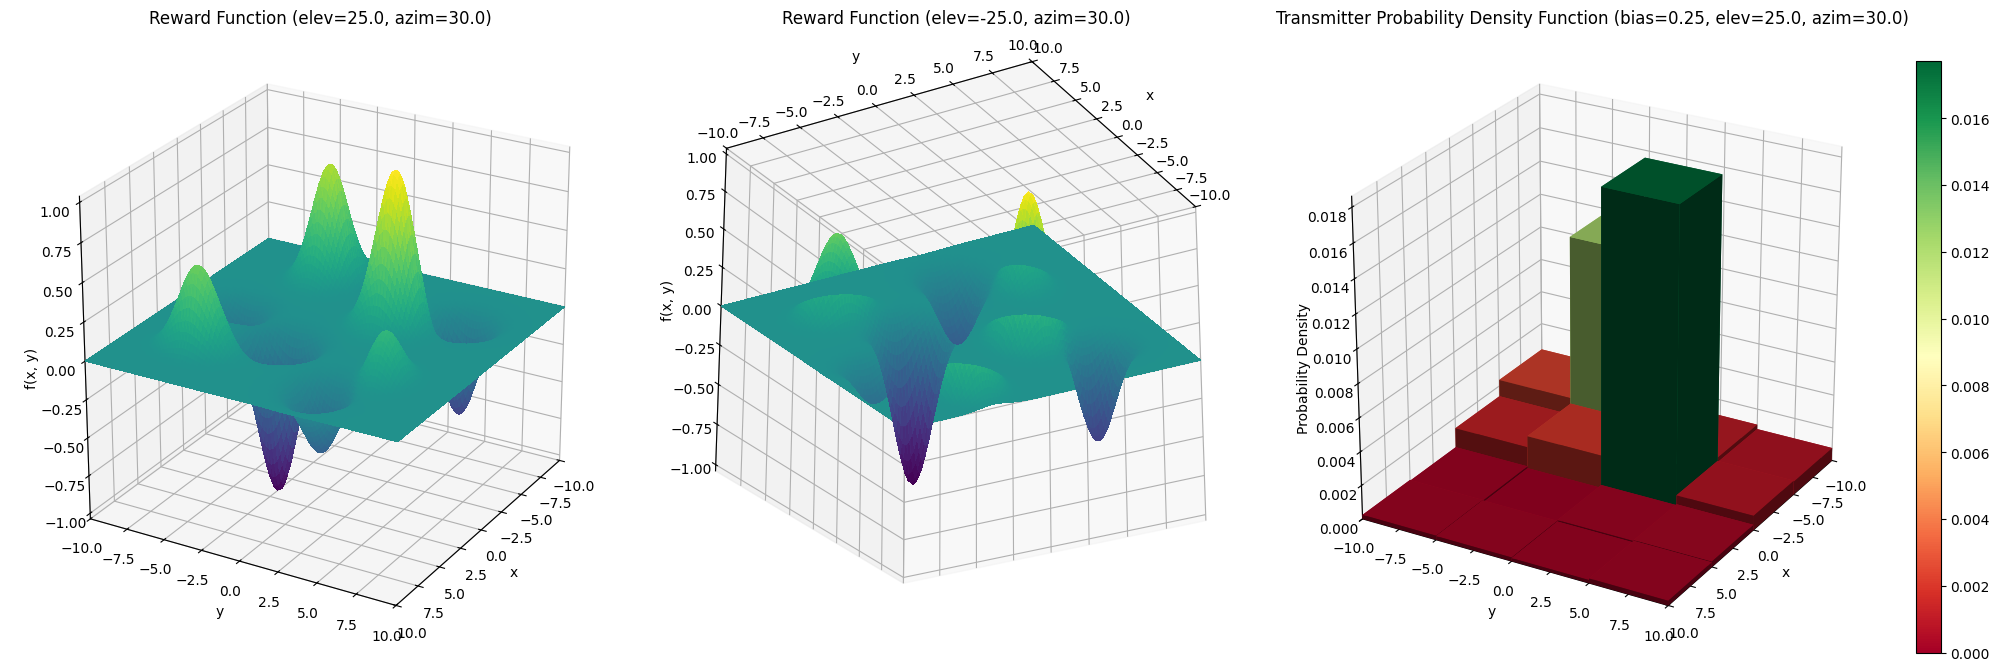

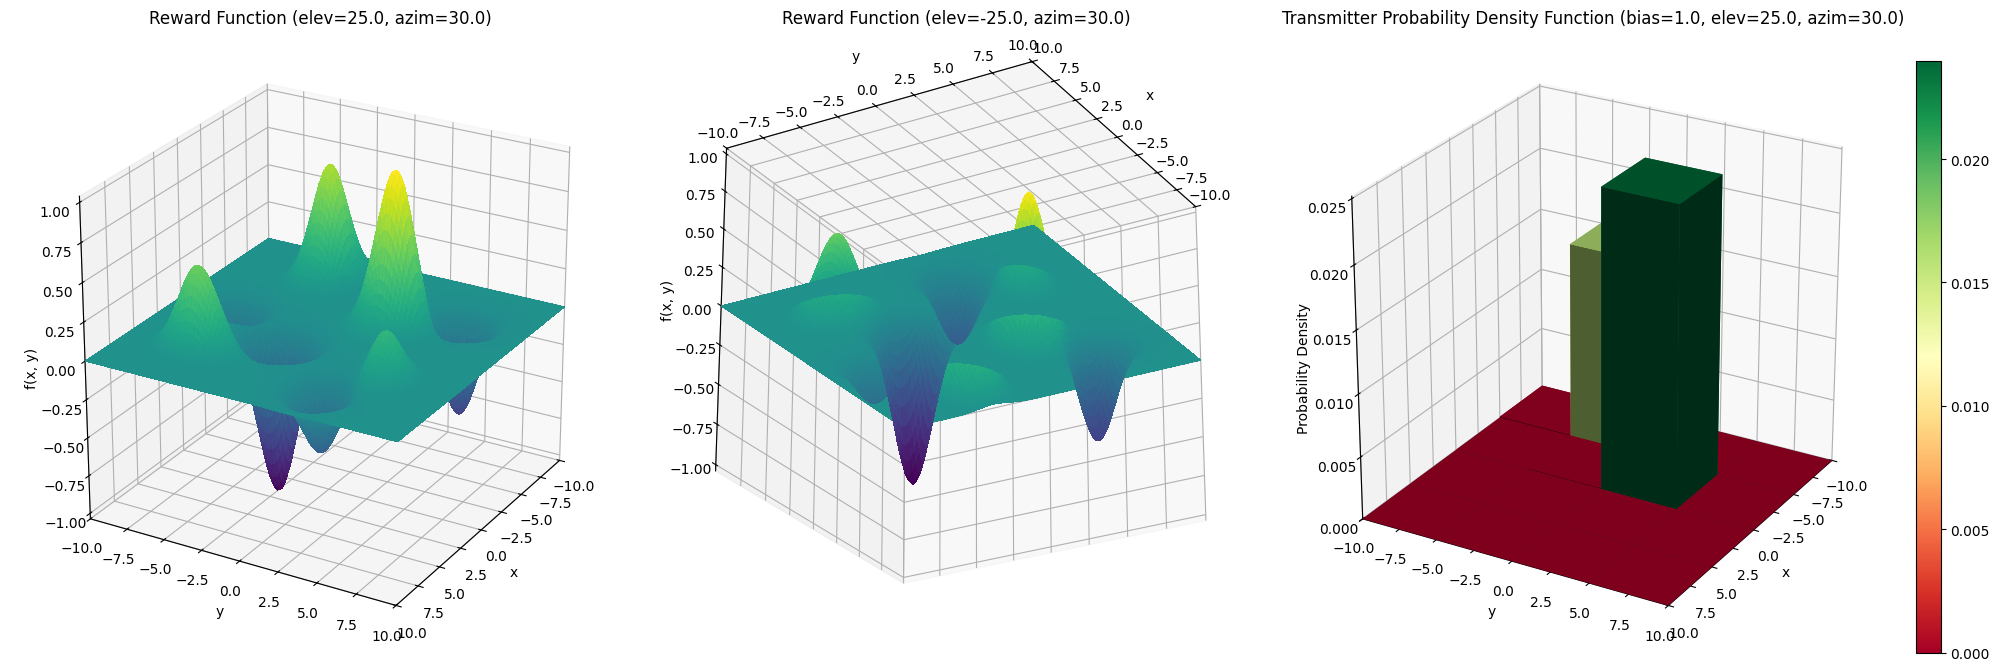

In [10]:
# define the list of biases to evaluate
biases = [-1.0, -0.15, -0.1, -0.05, 0.0, 0.25, 1.0]

# plot the transmitter for each bias
for bias in biases:
    fig, ax = plt.subplots(ncols=3, figsize=(20, 7), subplot_kw={"projection": "3d"})
    plot_function(ax[0], reward_function, elev=25.0)
    plot_function(ax[1], reward_function, elev=-25.0)
    plot_transmitter(ax[2], transmitter, bias, elev=25.0)
    # adjust the aspect ratio of each plot
    for axis in ax:
        axis.set_box_aspect((1, 1, 1), zoom=0.95)
    fig.tight_layout()
    plt.show()

## Conclusions

This playground provides an empirical view of how a two-dimensional `Transmitter` learns a stochastic policy over a continuous output space. It begins without prior preference, samples uniformly, and receives only scalar feedback for the coordinates it selects. From that interaction history, it progressively assigns more probability to regions whose rewards compare favorably with the shared running baseline.

The experiment also separates two mechanisms that are easy to conflate. Log-weight updates learn *which existing regions should be sampled more often*; midpoint splits determine *how finely those regions can be distinguished*. Since splitting is triggered by visits, the representation tends to become more detailed where the learned policy already allocates more interactions. In the reproduced run, this process concentrates both probability and spatial resolution around the region containing the reward function's global maximum.

The learned policy remains stochastic. Finite log-weights passed through a softmax leave every branch with nonzero probability, so lower-ranked regions can still be sampled and can still provide new evidence. This is not, by itself, a guarantee of convergence or adequate exploration under every configuration, but it prevents the module from becoming a hard deterministic selector during the demonstrated run.

Sampling bias then exposes several behaviors from the same learned state. Positive bias sharpens the distribution, moderately negative bias flattens it, and sufficiently negative bias reverses its ranking. Because bias is a transient sampling transformation, the exploration–exploitation profile can be changed without discarding or rewriting what the `Transmitter` has learned.

A standalone `Transmitter` learns without input context. Context-dependent behavior emerges when `Processor` combines `Receiver` and `Transmitter`. Examined in isolation, the module exhibits its intended behavior: it maintains and refines a probability distribution that increasingly favors outputs with higher expected reward, while allowing the sampling policy to be adjusted independently through bias.